<a href="https://colab.research.google.com/github/cu24250171/cu24250171-Divya-B.-Tech-CSE-A-3rd-year---Computer-Vision-labsheets/blob/main/LABSHEET_6_COMPUTER_VISION_LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAME - DIVYA

B.TECH CSE 'A' 3RD YEAR

CU24250171

ROLL NO. 17

1. Build a threshold-based segmentation tool with adjustable global and adaptive thresholds.

Original Image


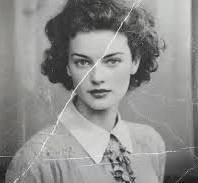

Grayscale Image


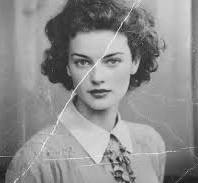

Global Threshold Segmentation


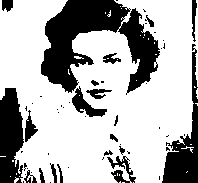

Adaptive Threshold Segmentation


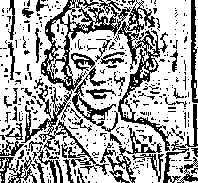

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

# Read the image
image = cv2.imread("/content/image.jpg")

# Convert image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Set global threshold value
threshold_value = 127

# Global thresholding
_, global_threshold = cv2.threshold(
    gray, threshold_value, 255, cv2.THRESH_BINARY
)

# Adaptive thresholding
adaptive_threshold = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

# Display original image
print("Original Image")
cv2_imshow(image)

# Display grayscale image
print("Grayscale Image")
cv2_imshow(gray)

# Display global threshold result
print("Global Threshold Segmentation")
cv2_imshow(global_threshold)

# Display adaptive threshold result
print("Adaptive Threshold Segmentation")
cv2_imshow(adaptive_threshold)

2. Develop a region-growing segmentation tool that segments an image starting from user-selected seed points.

Original Image


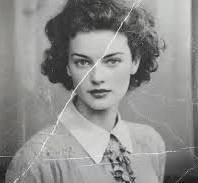

Grayscale Image


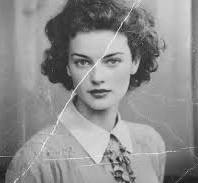

Region Growing Segmentation


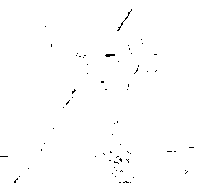

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Read the image
image = cv2.imread("/content/image.jpg")

# Convert image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Select seed point
x = 100
y = 100

# Get the seed pixel value
seed_value = gray[y, x]

# Set intensity difference (tolerance)
threshold = 20

# Create an empty mask
segmented = np.zeros_like(gray)

# Region growing using flood fill
mask = np.zeros((gray.shape[0] + 2, gray.shape[1] + 2), np.uint8)

cv2.floodFill(
    gray.copy(),
    mask,
    (x, y),
    255,
    loDiff=threshold,
    upDiff=threshold,
    flags=8
)

# Extract the segmented region
segmented = mask[1:-1, 1:-1] * 255

# Display images
print("Original Image")
cv2_imshow(image)

print("Grayscale Image")
cv2_imshow(gray)

print("Region Growing Segmentation")
cv2_imshow(segmented)

3. Create a split-merge segmentation demo on a textured or satellite image.

Mean intensity of regions:
Region 1 : 127.45
Region 2 : 148.97
Region 3 : 146.91
Region 4 : 147.09
Original Image


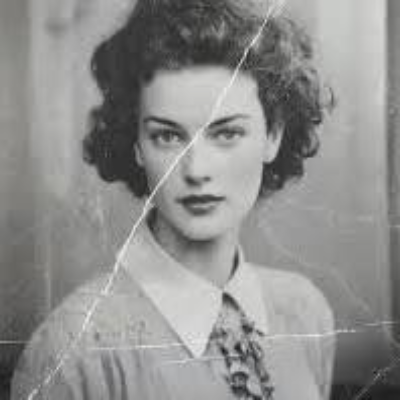

Split-Merge Segmentation


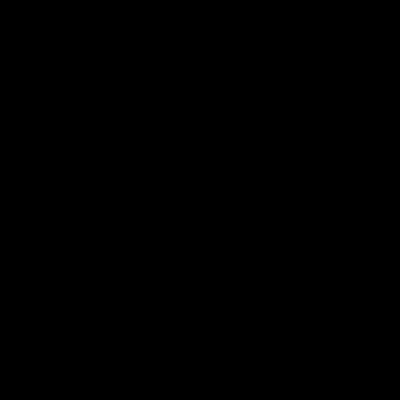

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
image = cv2.imread("/content/image.jpg")
image = cv2.resize(image,(400,400))
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
h , w = gray.shape
mid_h = h // 2
mid_w = w // 2
regions = [
    gray[0:mid_h,0:mid_w],
    gray[0:mid_h,mid_w:w],
    gray[mid_h:h,0:mid_w],
    gray[mid_h:h,mid_w:w]
]
means = [np.mean(region) for region in regions]
print("Mean intensity of regions:")
for i, mean in enumerate(means):
  print("Region", i + 1, ":",round(mean,2))
segmented = np.zeros_like(gray)
merge_threshold = 30
labels = [0,1,2,3]
for i in range(4):
  for j in range(i + 1,4):
    if abs(means[i] - means[j]) < merge_threshold:
      labels[j] = labels[i]
segmented[0:mid_h,0:mid_w] = labels[0] * 80
segmented[0:mid_h,mid_w:w] = labels[1] * 80
segmented[mid_h:h,0:mid_w] = labels[2] * 80
segmented[mid_h:h,mid_w:w] = labels[3] * 80
print("Original Image")
cv2_imshow(image)
print("Split-Merge Segmentation")
cv2_imshow(segmented)


4. Build a watershed segmentation tool to separate touching or overlapping objects(e.g.,coins or cells).

Original Image


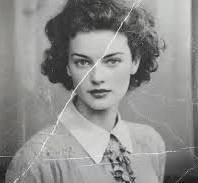

Binary Image


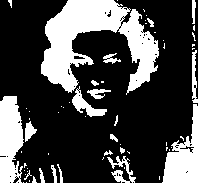

Watershed Segmentation


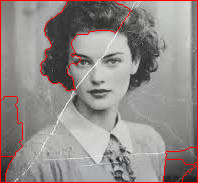

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
image = cv2.imread("/content/image.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
kernel = np.ones((3,3),np.uint8)
opening = cv2.morphologyEx(binary,cv2.MORPH_OPEN,kernel, iterations = 2)
sure_bg = cv2.dilate(opening,kernel,iterations=3)
dist_transform = cv2.distanceTransform(opening,cv2.DIST_L2,5)
_, sure_fg = cv2.threshold(dist_transform,0.5*dist_transform.max(),255,0)
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg,sure_fg)
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown==255] = 0
markers = cv2.watershed(image,markers)
result = image.copy()
result[markers == -1] = [0,0,255]
print("Original Image")
cv2_imshow(image)
print("Binary Image")
cv2_imshow(binary)
print("Watershed Segmentation")
cv2_imshow(result)

5. Develop a k-means or mean-shift colour segmentation tool that clusters image regions by color similarity.

Original Image


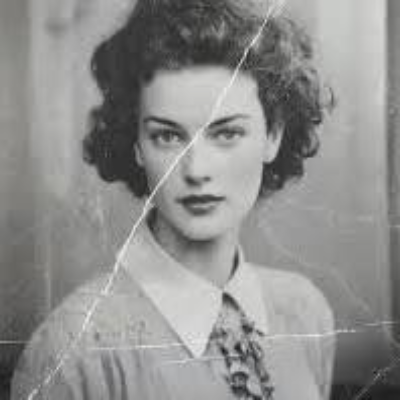

K-Means Color Segmented Image


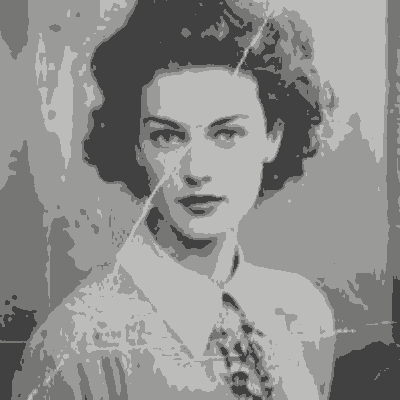

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Read the image
image = cv2.imread("/content/image.jpg")

# Convert image from BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize image
image = cv2.resize(image, (400, 400))

# Reshape image into a list of pixels
pixels = image.reshape((-1, 3))
pixels = np.float32(pixels)

# Number of color clusters
k = 4

# K-Means criteria
criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    100,
    0.2
)

# Apply K-Means clustering
_, labels, centers = cv2.kmeans(
    pixels,
    k,
    None,
    criteria,
    10,
    cv2.KMEANS_RANDOM_CENTERS
)

# Convert centers to integers
centers = np.uint8(centers)

# Replace each pixel with its cluster center
segmented_pixels = centers[labels.flatten()]

# Reshape pixels back into image
segmented_image = segmented_pixels.reshape(image.shape)

# Display original image
print("Original Image")
cv2_imshow(cv2.cvtColor(image, cv2.COLOR_RGB2BGR))

# Display segmented image
print("K-Means Color Segmented Image")
cv2_imshow(cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR))

6. Create an interactive foreground-extraction tool using a graph-based method such as GrabCut.

Original Image


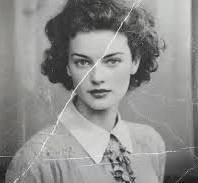

Extracted Foreground


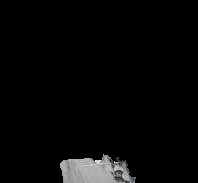

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Read the image
image = cv2.imread("/content/image.jpg")

# Create a mask
mask = np.zeros(image.shape[:2], np.uint8)

# Define a rectangle around the foreground object
x, y, w, h = 50, 50, 300, 300
rect = (x, y, w, h)

# Create background and foreground models
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

# Apply GrabCut
cv2.grabCut(
    image,
    mask,
    rect,
    bgd_model,
    fgd_model,
    5,
    cv2.GC_INIT_WITH_RECT
)

# Create final mask
final_mask = np.where(
    (mask == 2) | (mask == 0),
    0,
    1
).astype("uint8")

# Extract foreground
foreground = image * final_mask[:, :, np.newaxis]

# Display original image
print("Original Image")
cv2_imshow(image)

# Display extracted foreground
print("Extracted Foreground")
cv2_imshow(foreground)

7. Build a normalized-cut based segmentation demo that partitions an image into meaningful regions.

Original Image


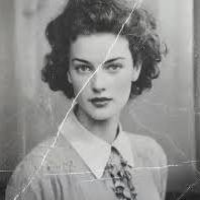

Normalized-Cut Based Segmentation Demo


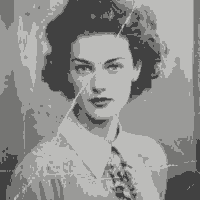

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Read the image
image = cv2.imread("/content/image.jpg")

# Resize image
image = cv2.resize(image, (200, 200))

# Convert image to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Reshape image into pixels
pixels = image_rgb.reshape((-1, 3)).astype(np.float32)

# Number of regions
k = 4

# K-Means is used to create initial groups
criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    100,
    0.2
)

_, labels, centers = cv2.kmeans(
    pixels,
    k,
    None,
    criteria,
    10,
    cv2.KMEANS_RANDOM_CENTERS
)

# Convert labels into an image
labels = labels.reshape((200, 200))

# Create segmented image
segmented = np.zeros_like(image_rgb)

for i in range(k):
    segmented[labels == i] = centers[i].astype(np.uint8)

# Convert back to BGR for display
segmented_bgr = cv2.cvtColor(segmented, cv2.COLOR_RGB2BGR)

# Display original image
print("Original Image")
cv2_imshow(image)

# Display segmented image
print("Normalized-Cut Based Segmentation Demo")
cv2_imshow(segmented_bgr)

8. Develop a medical image segmentation tool (e.g., isolating a tumour or organ outline from a grayscale scan).

Original Grayscale Medical Image


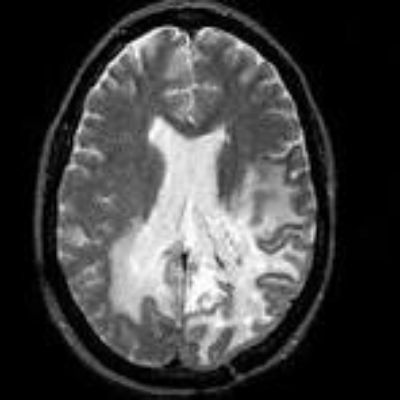

Blurred Image


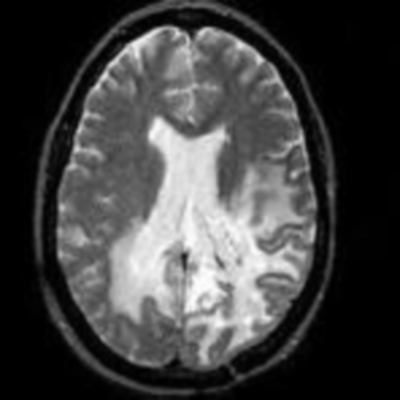

Segmented Medical Image


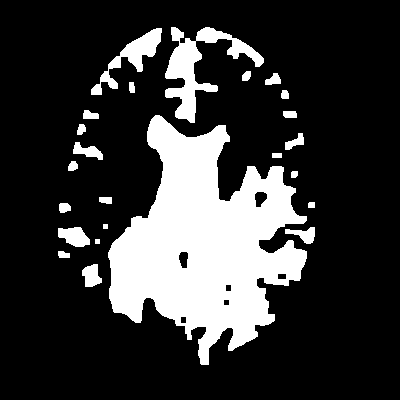

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Read the medical image in grayscale
image = cv2.imread("/content/medical_image.jpg", cv2.IMREAD_GRAYSCALE)

# Resize image
image = cv2.resize(image, (400, 400))

# Apply Gaussian blur to reduce noise
blur = cv2.GaussianBlur(image, (5, 5), 0)

# Apply thresholding
_, segmented = cv2.threshold(
    blur, 120, 255, cv2.THRESH_BINARY
)

# Remove small noise
kernel = np.ones((3, 3), np.uint8)
segmented = cv2.morphologyEx(
    segmented, cv2.MORPH_OPEN, kernel, iterations=2
)

# Fill small gaps in the segmented region
segmented = cv2.morphologyEx(
    segmented, cv2.MORPH_CLOSE, kernel, iterations=2
)

# Display original image
print("Original Grayscale Medical Image")
cv2_imshow(image)

# Display blurred image
print("Blurred Image")
cv2_imshow(blur)

# Display segmented region
print("Segmented Medical Image")
cv2_imshow(segmented)

9. Create a license-plate or text-region segmentation tool that isolates text areas from vehicle or document images.

Original Image


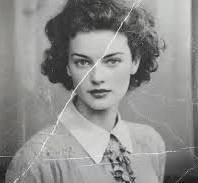

Binary Image


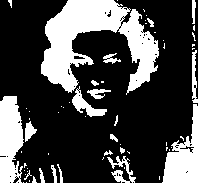

Detected Text Regions


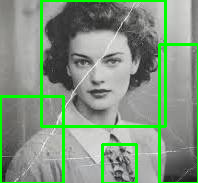

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Read the image
image = cv2.imread("/content/image.jpg")

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply thresholding
_, binary = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Create a rectangular kernel
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT, (15, 3)
)

# Connect nearby text characters
morph = cv2.morphologyEx(
    binary,
    cv2.MORPH_CLOSE,
    kernel
)

# Find contours
contours, _ = cv2.findContours(
    morph,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Copy image for displaying detected regions
result = image.copy()

# Draw bounding boxes around text regions
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)

    # Filter small and very large regions
    if w > 30 and h > 10 and w < 500 and h < 200:
        cv2.rectangle(
            result,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

# Display results
print("Original Image")
cv2_imshow(image)

print("Binary Image")
cv2_imshow(binary)

print("Detected Text Regions")
cv2_imshow(result)

10. Build an evalution dashboard that compares segmentation accuracy (loU / Dice score ) of different methods against ground-truth masks.

--------------------------------
Thresholding
IoU Score   : 0.5313
Dice Score  : 0.694
--------------------------------
K-Means
IoU Score   : 0.5333
Dice Score  : 0.6956
--------------------------------
GrabCut
IoU Score   : 0.2334
Dice Score  : 0.3784

BEST RESULTS
Best IoU Method: K-Means -> 0.5333
Best Dice Method: K-Means -> 0.6956


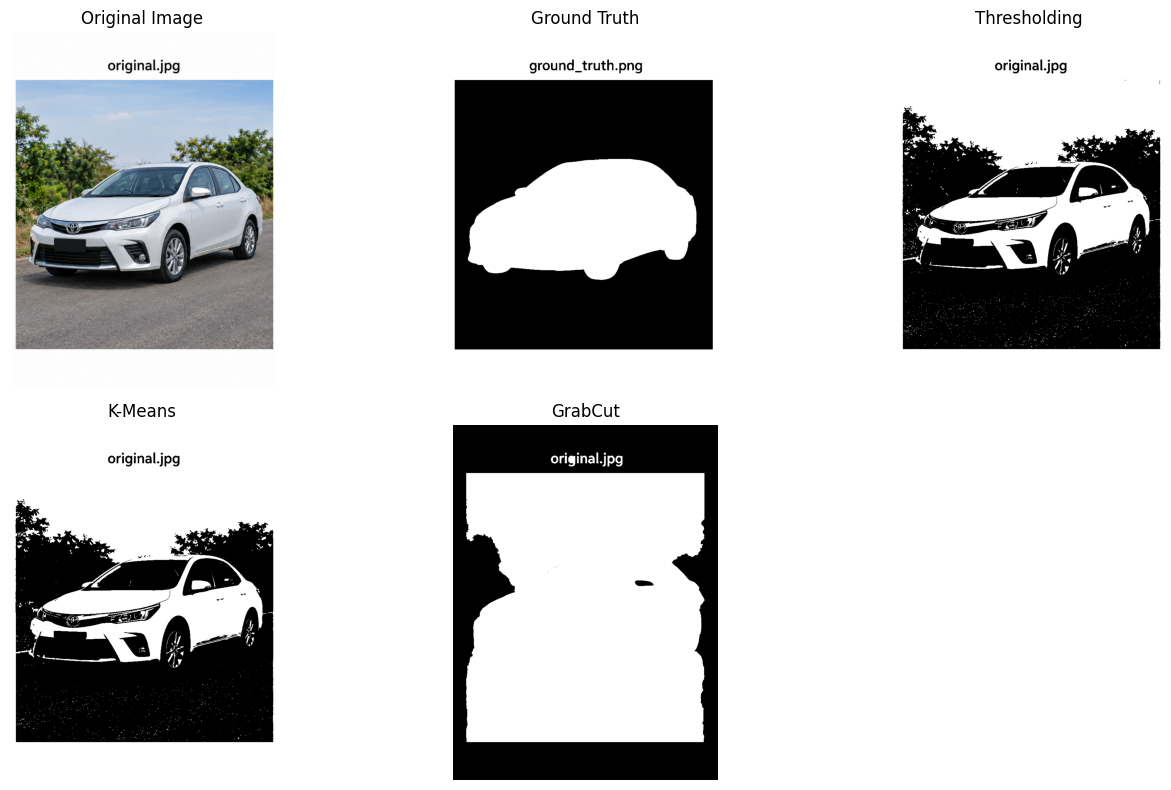

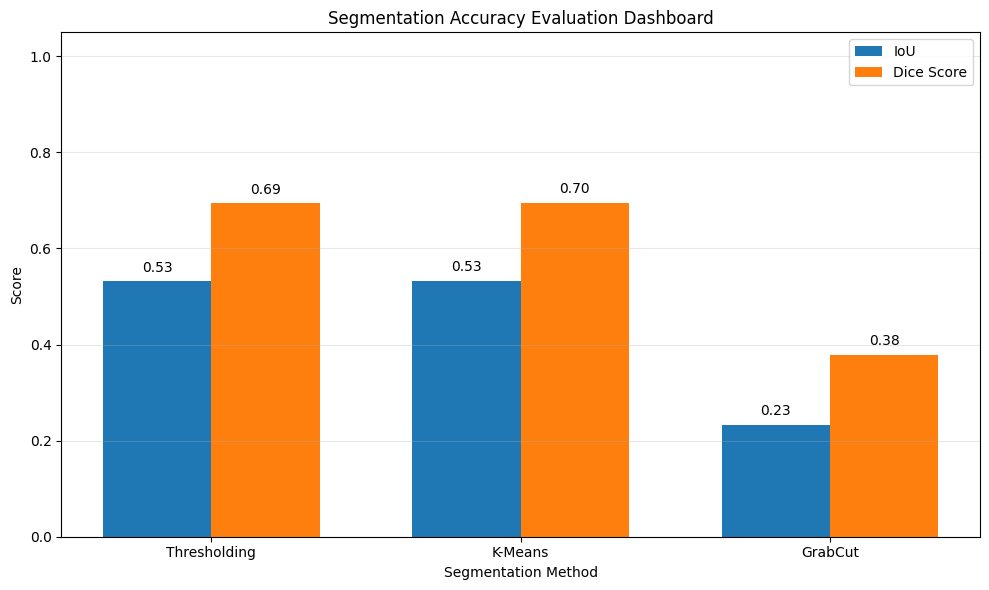

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
# 1. LOAD IMAGE AND GROUND-TRUTH MASK
image = cv2.imread("/content/original.png")

if image is None:
    print("Error: original.jpg not found!")
    exit()

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

ground_truth = cv2.imread("/content/ground_truth.png", cv2.IMREAD_GRAYSCALE)

if ground_truth is None:
    print("Error: ground_truth.png not found!")
    exit()


# Resize ground truth if necessary
ground_truth = cv2.resize(
    ground_truth,
    (image.shape[1], image.shape[0])
)

# Convert ground truth into binary mask
ground_truth = np.where(ground_truth > 127, 255, 0).astype(np.uint8)
# 2. THRESHOLDING SEGMENTATION
_, threshold_mask = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
# 3. K-MEANS SEGMENTATION
pixels = image.reshape((-1, 3))
pixels = np.float32(pixels)

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(pixels)

centers = np.uint8(kmeans.cluster_centers_)

segmented = centers[labels]

segmented = segmented.reshape(image.shape)

# Convert K-Means result to grayscale
kmeans_gray = cv2.cvtColor(
    segmented,
    cv2.COLOR_BGR2GRAY
)

# Create binary mask
_, kmeans_mask = cv2.threshold(
    kmeans_gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
# 4. GRABCUT SEGMENTATION
mask = np.zeros(image.shape[:2], np.uint8)

height, width = image.shape[:2]

# Rectangle covering most of the image
rect = (
    int(width * 0.05),
    int(height * 0.05),
    int(width * 0.90),
    int(height * 0.90)
)

background_model = np.zeros((1, 65), np.float64)
foreground_model = np.zeros((1, 65), np.float64)

cv2.grabCut(
    image,
    mask,
    rect,
    background_model,
    foreground_model,
    5,
    cv2.GC_INIT_WITH_RECT
)

grabcut_mask = np.where(
    (mask == cv2.GC_FGD) |
    (mask == cv2.GC_PR_FGD),
    255,
    0
).astype(np.uint8)
# 5. CALCULATE IoU
def calculate_iou(ground_truth, prediction):

    ground_truth_bool = ground_truth > 0
    prediction_bool = prediction > 0

    intersection = np.logical_and(
        ground_truth_bool,
        prediction_bool
    ).sum()

    union = np.logical_or(
        ground_truth_bool,
        prediction_bool
    ).sum()

    if union == 0:
        return 1.0

    return intersection / union
# 6. CALCULATE DICE SCORE
def calculate_dice(ground_truth, prediction):

    ground_truth_bool = ground_truth > 0
    prediction_bool = prediction > 0

    intersection = np.logical_and(
        ground_truth_bool,
        prediction_bool
    ).sum()

    total_pixels = (
        ground_truth_bool.sum() +
        prediction_bool.sum()
    )

    if total_pixels == 0:
        return 1.0

    return (2 * intersection) / total_pixels
# 7. CALCULATE SCORES FOR EACH METHOD
methods = {
    "Thresholding": threshold_mask,
    "K-Means": kmeans_mask,
    "GrabCut": grabcut_mask
}

iou_scores = []
dice_scores = []

for method, mask in methods.items():

    iou = calculate_iou(
        ground_truth,
        mask
    )

    dice = calculate_dice(
        ground_truth,
        mask
    )

    iou_scores.append(iou)
    dice_scores.append(dice)

    print("--------------------------------")
    print(method)
    print("IoU Score   :", round(iou, 4))
    print("Dice Score  :", round(dice, 4))
# 8. FIND BEST METHOD
best_iou_index = np.argmax(iou_scores)
best_dice_index = np.argmax(dice_scores)

best_iou_method = list(methods.keys())[best_iou_index]
best_dice_method = list(methods.keys())[best_dice_index]

print("\n================================")
print("BEST RESULTS")
print("================================")

print(
    "Best IoU Method:",
    best_iou_method,
    "->",
    round(iou_scores[best_iou_index], 4)
)

print(
    "Best Dice Method:",
    best_dice_method,
    "->",
    round(dice_scores[best_dice_index], 4)
)
# 9. DISPLAY SEGMENTATION RESULTS
plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(ground_truth, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(threshold_mask, cmap="gray")
plt.title("Thresholding")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(kmeans_mask, cmap="gray")
plt.title("K-Means")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(grabcut_mask, cmap="gray")
plt.title("GrabCut")
plt.axis("off")

plt.tight_layout()
plt.show()
# 10. IoU AND DICE DASHBOARD

x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    iou_scores,
    width,
    label="IoU"
)

plt.bar(
    x + width / 2,
    dice_scores,
    width,
    label="Dice Score"
)

plt.xticks(
    x,
    methods.keys()
)

plt.ylim(0, 1.05)

plt.ylabel("Score")

plt.xlabel("Segmentation Method")

plt.title(
    "Segmentation Accuracy Evaluation Dashboard"
)

plt.legend()

# Add score values above bars
for i in range(len(methods)):

    plt.text(
        i - width / 2,
        iou_scores[i] + 0.02,
        f"{iou_scores[i]:.2f}",
        ha="center"
    )

    plt.text(
        i + width / 2,
        dice_scores[i] + 0.02,
        f"{dice_scores[i]:.2f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()